In [2]:
# Import Libraries

import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('1) iris.csv')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
# Task 1 - Data Cleaning

# Display first 10 rows
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [5]:
# Display last 10 rows
df.tail(10)

,sepal_length,sepal_width,petal_length,petal_width,species
140,6.7,3.1,5.6,2.4,virginica
141,6.9,3.1,5.1,2.3,virginica
142,5.8,2.7,5.1,1.9,virginica
143,6.8,3.2,5.9,2.3,virginica
144,6.7,3.3,5.7,2.5,virginica
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [6]:
# Display size of Iris dataset

df.size

750

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [8]:
# Summary statistics
print("\nSummary statistics:\n", df.describe())


Summary statistics:
        sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [9]:
df.isnull()

,sepal_length,sepal_width,petal_length,petal_width,species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [10]:
# 1. Check for missing values
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [11]:
# 2. Remove duplicates

print("\nDuplicates Before : ", df.duplicated().sum())
df.drop_duplicates(inplace = True)
print("\nDuplicates After : ",df.duplicated().sum())


Duplicates Before :  3

Duplicates After :  0


In [12]:
# 3. Check for inconsistent data types

print("\nData Types:\n",df.dtypes)


Data Types:
 sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [13]:
# Task 2 - Exploratory Data Analysis (EDA)

# Check Unique Classes
print("Species Distribution:\n ",df['species'].value_counts())

Species Distribution:
  species
versicolor    50
virginica     49
setosa        48
Name: count, dtype: int64


In [14]:
# Correlation matrix

print("Correlation matrix:\n ", df.corr(numeric_only = True))

Correlation matrix:
                sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.109321      0.871305     0.817058
sepal_width      -0.109321     1.000000     -0.421057    -0.356376
petal_length      0.871305    -0.421057      1.000000     0.961883
petal_width       0.817058    -0.356376      0.961883     1.000000


In [15]:
# Detect outliers using IQR method

Q1 = df['sepal_length'].quantile(0.25)
Q3 = df['sepal_width'].quantile(0.75)

IQR = Q3 - Q1

Outliers = df[(df['sepal_length'] < (Q1 - 1.5 * IQR)) | (df['sepal_width'] > (Q3 + 1.5 * IQR))]
print(f"Outliers in Sepal Length -\n {Outliers}")

Outliers in Sepal Length -
      sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[147 rows x 5 columns]


In [16]:
# Detect outliers using IQR method

Q1 = df['petal_length'].quantile(0.25)
Q3 = df['petal_width'].quantile(0.75)

IQR = Q3 - Q1

Outliers = df[(df['petal_length'] < (Q1 - 1.5 * IQR)) | (df['petal_width'] > (Q3 + 1.5 * IQR))]
print(f"Outliers in Petal Length -\n {Outliers}")

Outliers in Petal Length -
      sepal_length  sepal_width  petal_length  petal_width    species
2             4.7          3.2           1.3          0.2     setosa
13            4.3          3.0           1.1          0.1     setosa
14            5.8          4.0           1.2          0.2     setosa
16            5.4          3.9           1.3          0.4     setosa
22            4.6          3.6           1.0          0.2     setosa
35            5.0          3.2           1.2          0.2     setosa
36            5.5          3.5           1.3          0.2     setosa
38            4.4          3.0           1.3          0.2     setosa
40            5.0          3.5           1.3          0.3     setosa
41            4.5          2.3           1.3          0.3     setosa
42            4.4          3.2           1.3          0.2     setosa
100           6.3          3.3           6.0          2.5  virginica
104           6.5          3.0           5.8          2.2  virginica
109   

In [17]:
# Task 3 - Basic Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

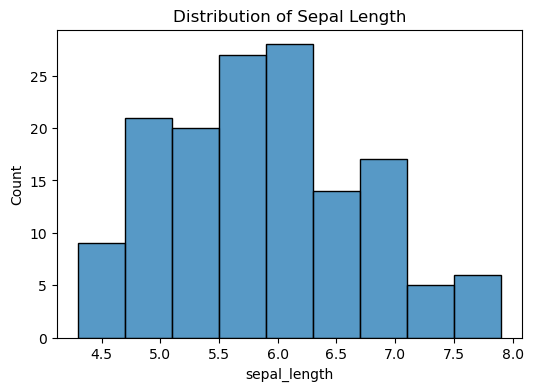

In [18]:
# 1️ Histogram

plt.figure(figsize = (6,4))
sns.histplot(df['sepal_length'])
plt.title("Distribution of Sepal Length")
plt.show()

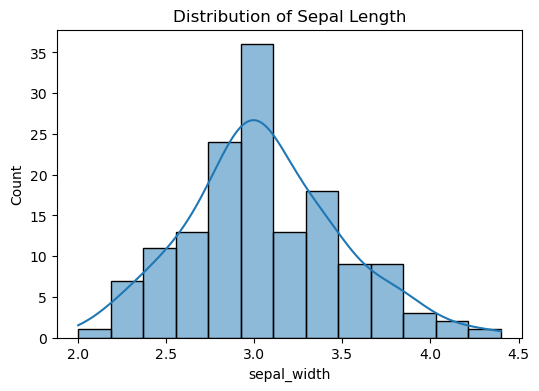

In [18]:
plt.figure(figsize = (6,4))
sns.histplot(df['sepal_width'], kde = True)
plt.title("Distribution of Sepal Length")
plt.show()

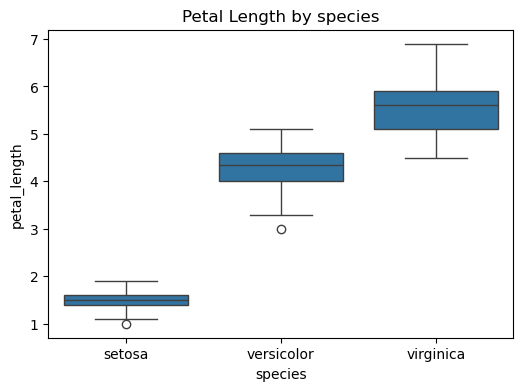

In [19]:
# 2️ Boxplot by species

plt.figure(figsize = (6,4))
sns.boxplot(x = 'species', y = 'petal_length', data = df)
plt.title('Petal Length by species')
plt.show()

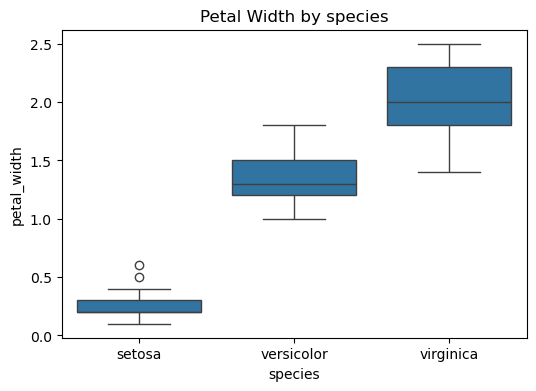

In [20]:
plt.figure(figsize = (6,4))
sns.boxplot(x = 'species', y = 'petal_width', data = df)
plt.title('Petal Width by species')
plt.show()

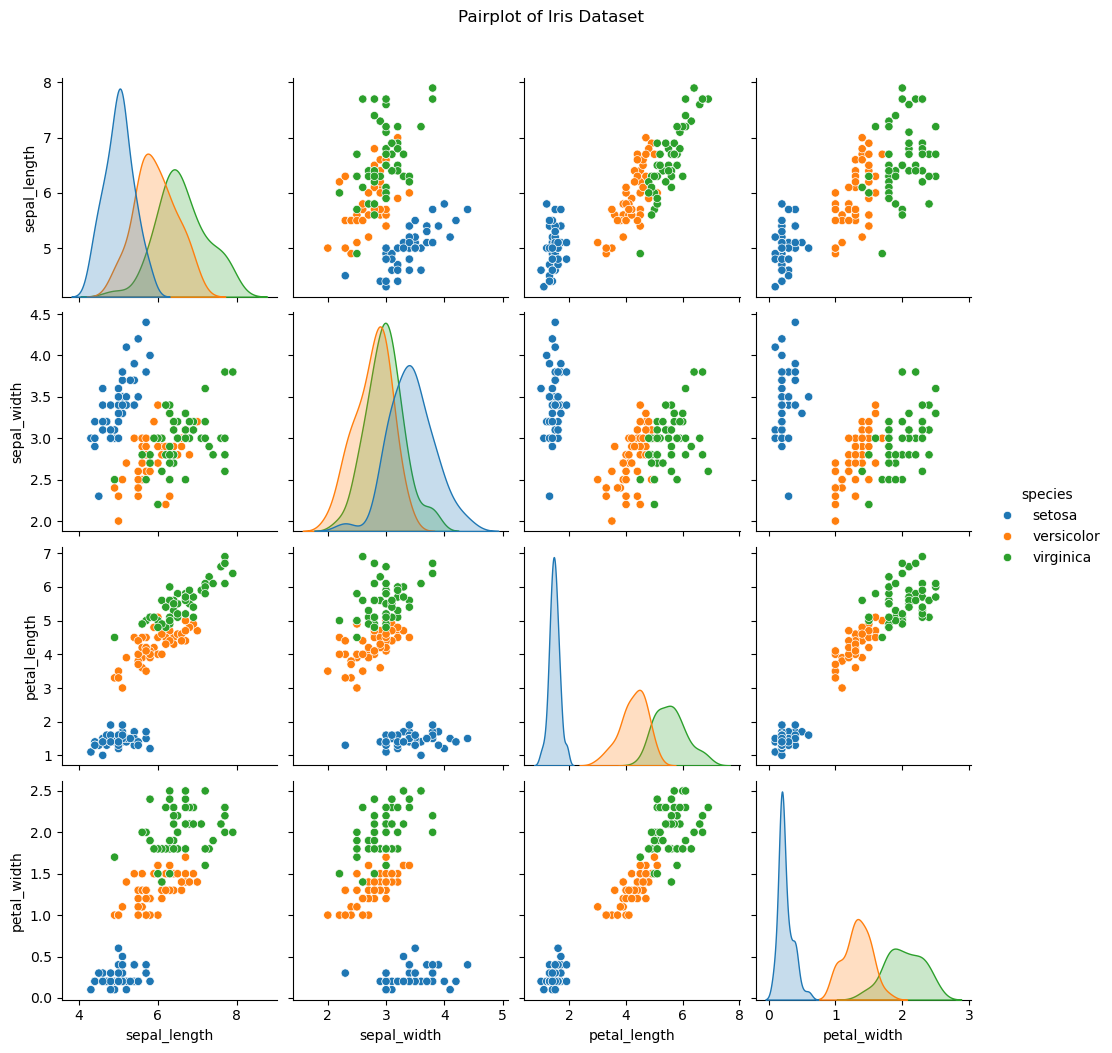

In [20]:
# 3. Pairplot

sns.pairplot(df, hue='species', diag_kind='kde')
plt.suptitle("Pairplot of Iris Dataset", y = 1.05)
plt.show()


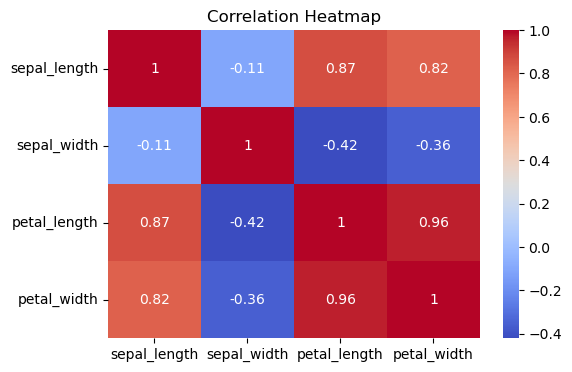

In [21]:
# 4. Correlation heatmap

plt.figure(figsize = (6,4))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
#  Task - Logistic Regression (Supervised Classification)

# Goal: Predict flower species based on sepal/petal measurements.


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [23]:
# Features and target

X = df.iloc[:, 0:4]
y = df['species']

In [24]:
# split data

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state = 42)

In [25]:
# Train Model 
model = LogisticRegression(max_iter = 200)
model.fit(X_train, y_train)


LogisticRegression(max_iter=200)

In [26]:
# Predict
y_pred = model.predict(X_test)

In [27]:
# Evaluate

print("\nAccuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report :\n ",classification_report(y_test, y_pred))

print("\nConfusion Matrix :\n",confusion_matrix(y_test, y_pred))


Accuracy : 0.9333333333333333

Classification Report :
                precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.90      0.90      0.90        10
   virginica       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Confusion Matrix :
 [[11  0  0]
 [ 0  9  1]
 [ 0  1  8]]


In [ ]:
# Task - K-Means Clustering (Unsupervised Learning)

# Goal: Group data points into clusters (without knowing their labels).


In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [29]:
# Select features for clustering
X = df.iloc[:, 0:4]

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)


In [30]:
# Evaluate clustering

silhouette = silhouette_score(X, df['cluster'])
print(f"Silhouette Score: {silhouette:.3f}")


Silhouette Score: 0.549


In [31]:
# Compare predicted clusters with actual species

ct = pd.crosstab(df['species'], df['cluster'])
print("Cluster vs Actual Species:\n", ct)


Cluster vs Actual Species:
 cluster      0   1   2
species               
setosa       0   0  48
versicolor  47   3   0
virginica   13  36   0


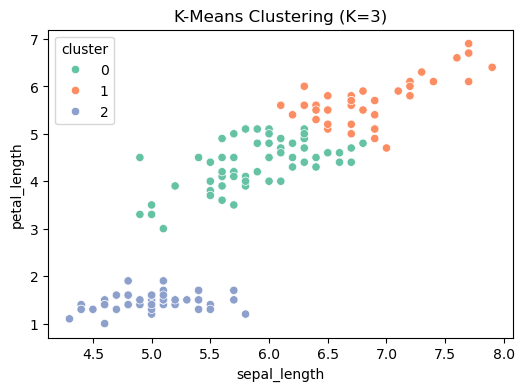

In [32]:
# Visualize clusters

plt.figure(figsize=(6,4))
sns.scatterplot(x='sepal_length', y='petal_length', hue='cluster', data=df, palette='Set2')
plt.title("K-Means Clustering (K=3)")
plt.show()